<div align="center">

# 🔎 Web Intelligence & NLP
## Keyword and Topic Analysis

**Notebook 05 — Extracting Themes, Keywords, and Topic-Level Sentiment**

![NLP](https://images.unsplash.com/photo-1555949963-ff9fe0c870eb?auto=format&fit=crop&w=1600&q=80)

</div>

---

### Project
**Web Intelligence and NLP-Based Sentiment Analytics**

### Notebook Objective
This notebook moves beyond individual sentiment labels and extracts **what people are actually talking about**.

We will combine:

- keyword extraction
- TF-IDF keyword ranking
- word frequency
- bigram/trigram analysis
- LDA topic modeling
- NMF topic modeling
- topic interpretation
- document-topic assignment
- topic distribution
- sentiment × topic analysis
- optional advanced keyword extraction

> **Important dataset limitation:** the current Quotes to Scrape dataset is a small practice corpus and does not contain product reviews, ratings, or human-labeled business topics. Topic names therefore need to be interpreted from the extracted words rather than treated as verified real-world categories.


## 🧭 Notebook Position in the Project

```text
01 Web Scraping
      ↓
02 Data Cleaning & EDA
      ↓
03 NLP Preprocessing
      ↓
04 Sentiment Analysis
      ↓
05 Keyword & Topic Analysis  ← YOU ARE HERE
      ↓
06 Final Insights
      ↓
Streamlit Dashboard
```

### Input

```text
data/final/nlp_ready_quotes.csv
data/final/sentiment_analysis_results.csv
```

### Outputs

```text
data/final/keyword_analysis.csv
data/final/topic_analysis.csv
data/final/topic_summary.csv
outputs/figures/
```


# 1. Setup and Imports

We first import the libraries required for text analysis, visualization, topic modeling, and output management.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Project Paths

The notebook is designed to run from the `notebooks/` directory or from the project root. We use `Path` objects so the workflow remains portable across operating systems.

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
FINAL_DATA_DIR = DATA_DIR / "final"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FINAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

NLP_FILE = FINAL_DATA_DIR / "nlp_ready_quotes.csv"
SENTIMENT_FILE = FINAL_DATA_DIR / "sentiment_analysis_results.csv"

KEYWORD_OUTPUT = FINAL_DATA_DIR / "keyword_analysis.csv"
TOPIC_OUTPUT = FINAL_DATA_DIR / "topic_analysis.csv"
TOPIC_SUMMARY_OUTPUT = FINAL_DATA_DIR / "topic_summary.csv"

print("Project root:", PROJECT_ROOT)
print("NLP input:", NLP_FILE)
print("Sentiment input:", SENTIMENT_FILE)

Project root: D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP
NLP input: D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\final\nlp_ready_quotes.csv
Sentiment input: D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\final\sentiment_analysis_results.csv


# 3. Load NLP-Ready Data

The primary text source is the dataset generated by **Notebook 03 — NLP Preprocessing**.

The sentiment results from Notebook 04 are also loaded when available so that we can connect discovered topics with sentiment.

In [3]:
if not NLP_FILE.exists():
    raise FileNotFoundError(
        f"NLP dataset not found: {NLP_FILE}\n"
        "Run 03_NLP_Preprocessing.ipynb first."
    )

df = pd.read_csv(NLP_FILE)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (100, 19)


,quote_id,quote_text,author,tags,source_url,text_length,original_text,normalized_text,tokens,filtered_tokens,lemmatized_tokens,stemmed_tokens,processed_text,original_char_count,processed_char_count,original_word_count,processed_word_count,bigrams,trigrams
0,1,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,Albert Einstein,"change, deep-thoughts, thinking, world",https://quotes.toscrape.com/,115,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,the world as we have created it is a process of our thinking it cannot be changed without changing our thinking,"['the', 'world', 'as', 'we', 'have', 'created', 'it', 'is', 'a', 'process', 'of', 'our', 'thinking', 'it', 'can', 'n...","['world', 'created', 'process', 'thinking', 'changed', 'without', 'changing', 'thinking']","['world', 'created', 'process', 'thinking', 'changed', 'without', 'changing', 'thinking']","['world', 'creat', 'process', 'think', 'chang', 'without', 'chang', 'think']",world created process thinking changed without changing thinking,115,64,22,8,"['world created', 'created process', 'process thinking', 'thinking changed', 'changed without', 'without changing', ...","['world created process', 'created process thinking', 'process thinking changed', 'thinking changed without', 'chang..."
1,2,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",J.K. Rowling,"abilities, choices",https://quotes.toscrape.com/,85,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",it is our choices harry that show what we truly are far more than our abilities,"['it', 'is', 'our', 'choices', 'harry', 'that', 'show', 'what', 'we', 'truly', 'are', 'far', 'more', 'than', 'our', ...","['choices', 'harry', 'show', 'truly', 'far', 'abilities']","['choice', 'harry', 'show', 'truly', 'far', 'ability']","['choic', 'harri', 'show', 'truli', 'far', 'abil']",choice harry show truly far ability,85,35,16,6,"['choice harry', 'harry show', 'show truly', 'truly far', 'far ability']","['choice harry show', 'harry show truly', 'show truly far', 'truly far ability']"
2,3,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything...,Albert Einstein,"inspirational, life, live, miracle, miracles",https://quotes.toscrape.com/,131,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything...,there are only two ways to live your life one is as though nothing is a miracle the other is as though everything is...,"['there', 'are', 'only', 'two', 'ways', 'to', 'live', 'your', 'life', 'one', 'is', 'as', 'though', 'nothing', 'is', ...","['two', 'ways', 'live', 'life', 'one', 'though', 'nothing', 'miracle', 'though', 'everything', 'miracle']","['two', 'way', 'live', 'life', 'one', 'though', 'nothing', 'miracle', 'though', 'everything', 'miracle']","['two', 'way', 'live', 'life', 'one', 'though', 'noth', 'miracl', 'though', 'everyth', 'miracl']",two way live life one though nothing miracle though everything miracle,131,70,26,11,"['two way', 'way live', 'live life', 'life one', 'one though', 'though nothing', 'nothing miracle', 'miracle though'...","['two way live', 'way live life', 'live life one', 'life one though', 'one though nothing', 'though nothing miracle'..."
3,4,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",Jane Austen,"aliteracy, books, classic, humor",https://quotes.toscrape.com/,104,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",the person be it gentleman or lady who has not pleasure in a good novel must be intolerably stupid,"['the', 'person', 'be', 'it', 'gentleman', 'or', 'lady', 'who', 'has', 'not', 'pleasure', 'in', 'a', 'good', 'novel'...","['person', 'gentleman', 'lady', '

In [4]:
if SENTIMENT_FILE.exists():
    sentiment_df = pd.read_csv(SENTIMENT_FILE)
    print(f"Sentiment dataset shape: {sentiment_df.shape}")
else:
    sentiment_df = None
    print("Sentiment results not found. Topic analysis will continue without sentiment linkage.")

Sentiment dataset shape: (100, 10)


## 4. Validate Required Columns

For topic modeling, the most important field is `processed_text`.

The notebook also supports `quote_id`, `original_text`, `author`, and `sentiment` when those columns exist.

In [5]:
if "processed_text" not in df.columns:
    raise ValueError("Required column 'processed_text' is missing.")

df["processed_text"] = (
    df["processed_text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df = df[df["processed_text"].ne("")].copy()
df = df.reset_index(drop=True)

print("Validated rows:", len(df))
print("Empty processed texts:", df["processed_text"].eq("").sum())

Validated rows: 100
Empty processed texts: 0


# 5. Keyword Analysis

## 5.1 Word Frequency

Word frequency provides a simple view of the most repeated terms in the corpus.

It is useful for exploration, but raw frequency alone can overemphasize common words. That is why we will also use TF-IDF.

In [6]:
from collections import Counter

all_tokens = " ".join(df["processed_text"]).split()
word_counts = Counter(all_tokens)

word_frequency = (
    pd.DataFrame(word_counts.items(), columns=["keyword", "frequency"])
    .sort_values("frequency", ascending=False)
    .reset_index(drop=True)
)

display(word_frequency.head(20))

,keyword,frequency
0,love,24
1,life,17
2,one,17
3,think,14
4,make,14
5,never,13
6,thing,10
7,book,10
8,like,9
9,good,8


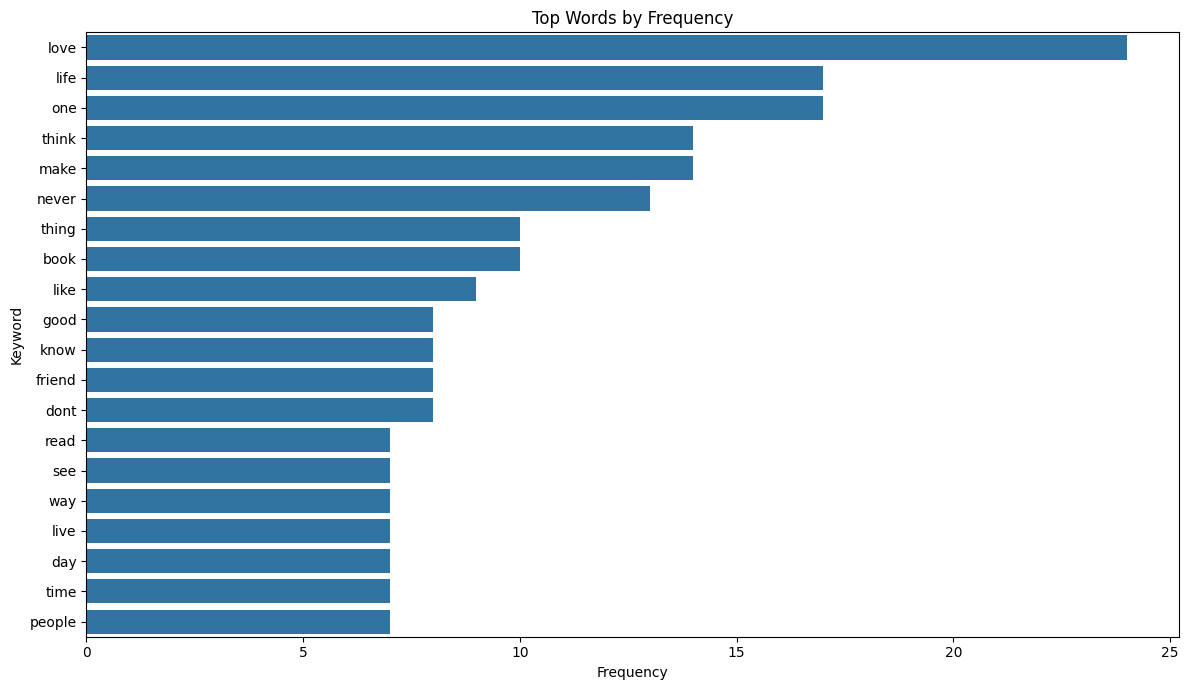

In [7]:
top_n = min(20, len(word_frequency))

plt.figure(figsize=(12, 7))
sns.barplot(
    data=word_frequency.head(top_n),
    x="frequency",
    y="keyword"
)
plt.title("Top Words by Frequency")
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.tight_layout()
plt.show()

### Observation

Word frequency identifies recurring vocabulary, but it does not tell us whether a word is **distinctive** to a document or merely common across the corpus.

Next, we use TF-IDF.

## 5.2 TF-IDF Keyword Ranking

**TF-IDF (Term Frequency–Inverse Document Frequency)** gives higher importance to terms that are frequent in a document but relatively uncommon across the full corpus.

Formula:

```text
TF-IDF = Term Frequency × Inverse Document Frequency
```

This is useful for discovering document-specific or corpus-distinctive keywords.

In [8]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df["processed_text"])
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Number of features:", len(feature_names))

TF-IDF matrix shape: (100, 1474)
Number of features: 1474


In [9]:
# Average TF-IDF score across the complete corpus
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

tfidf_keywords = (
    pd.DataFrame({
        "keyword": feature_names,
        "mean_tfidf": mean_tfidf
    })
    .sort_values("mean_tfidf", ascending=False)
    .reset_index(drop=True)
)

display(tfidf_keywords.head(30))

,keyword,mean_tfidf
0,love,0.025317
1,life,0.022377
2,one,0.022093
3,never,0.019589
4,book,0.017744
5,thing,0.016790
6,think,0.015165
7,know,0.015152
8,like,0.014778
9,people,0.014629


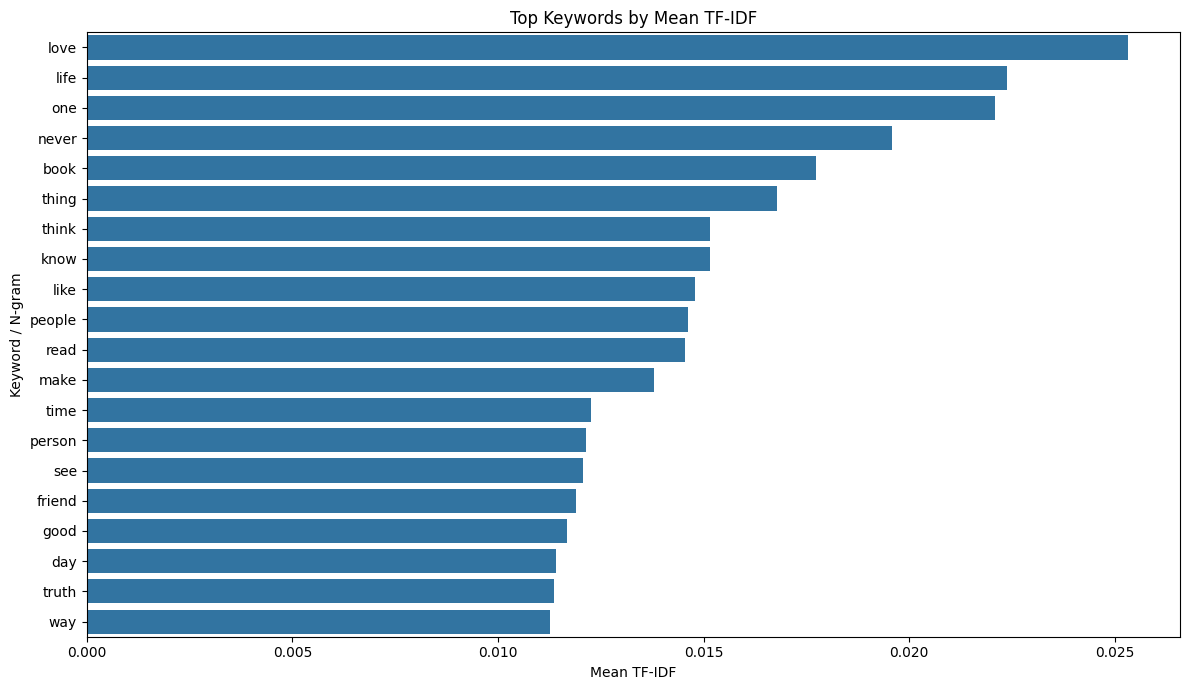

In [10]:
top_n = min(20, len(tfidf_keywords))

plt.figure(figsize=(12, 7))
sns.barplot(
    data=tfidf_keywords.head(top_n),
    x="mean_tfidf",
    y="keyword"
)
plt.title("Top Keywords by Mean TF-IDF")
plt.xlabel("Mean TF-IDF")
plt.ylabel("Keyword / N-gram")
plt.tight_layout()
plt.show()

## 5.3 Per-Document Top Keywords

For practical intelligence, it is useful to know which terms are most important **inside each individual document**.

In [11]:
def top_terms_for_document(row_index, matrix, features, top_k=8):
    row = matrix[row_index].toarray().ravel()
    if not np.any(row):
        return []

    top_indices = row.argsort()[::-1][:top_k]
    return [
        (features[i], round(float(row[i]), 4))
        for i in top_indices
        if row[i] > 0
    ]

df["top_tfidf_keywords"] = [
    top_terms_for_document(i, tfidf_matrix, feature_names, top_k=8)
    for i in range(len(df))
]

display(df[["processed_text", "top_tfidf_keywords"]].head(10))

,processed_text,top_tfidf_keywords
0,world created process thinking changed without changing thinking,"[(thinking, 0.385), (world created, 0.2647), (thinking changed, 0.2647), (process thinking, 0.2647), (process, 0.264..."
1,choice harry show truly far ability,"[(truly far, 0.3098), (ability, 0.3098), (show truly, 0.3098), (show, 0.3098), (harry show, 0.3098), (far ability, 0..."
2,two way live life one though nothing miracle though everything miracle,"[(miracle, 0.3881), (though, 0.3561), (nothing miracle, 0.2292), (miracle though, 0.2292), (one though, 0.2292), (th..."
3,person gentleman lady pleasure good novel must intolerably stupid,"[(pleasure good, 0.2543), (pleasure, 0.2543), (must intolerably, 0.2543), (novel must, 0.2543), (person gentleman, 0..."
4,imperfection beauty madness genius better absolutely ridiculous absolutely boring,"[(absolutely, 0.4072), (absolutely ridiculous, 0.2405), (absolutely boring, 0.2405), (madness genius, 0.2405), (madn..."
5,try become man success rather become man value,"[(become man, 0.427), (become, 0.3669), (man, 0.3475), (try become, 0.2522), (value, 0.2522), (man success, 0.2522),..."
6,better hated loved,"[(hated loved, 0.4673), (hated, 0.4673), (better hated, 0.4673), (loved, 0.4288), (better, 0.4015)]"
7,failed ive found way wont work,"[(wont work, 0.3101), (wont, 0.3101), (way wont, 0.3101), (work, 0.3101), (ive found, 0.3101), (found way, 0.3101), ..."
8,woman like tea bag never know strong hot water,"[(woman like, 0.2577), (strong, 0.2577), (never know, 0.2577), (tea bag, 0.2577), (like tea, 0.2577), (water, 0.2577..."
9,day without sunshine like know night,"[(sunshine like, 0.331), (sunshine, 0.331), (like know, 0.331), (night, 0.331), (without sunshine, 0.331), (know nig..."


# 6. N-Gram Analysis

Single words can miss important phrases.

Examples:

```text
machine learning
customer service
high quality
great experience
```

We therefore inspect:

- unigrams → one word
- bigrams → two-word phrases
- trigrams → three-word phrases


In [12]:
def ngram_frequency(text_series, n=2, top_k=20):
    vectorizer = CountVectorizer(
        ngram_range=(n, n),
        lowercase=False,
        min_df=1
    )
    matrix = vectorizer.fit_transform(text_series)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())

    return (
        pd.DataFrame({"ngram": terms, "frequency": counts})
        .sort_values("frequency", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )

bigrams = ngram_frequency(df["processed_text"], n=2, top_k=20)
trigrams = ngram_frequency(df["processed_text"], n=3, top_k=20)

print("Top Bigrams")
display(bigrams)

print("Top Trigrams")
display(trigrams)

Top Bigrams


,ngram,frequency
0,happens drink,3
1,fairy tale,3
2,indifference opposite,3
3,intelligent read,2
4,every day,2
5,going mess,2
6,become man,2
7,best friend,2
8,everyone else,2
9,die time,2


Top Trigrams


,ngram,frequency
0,intelligent read fairy,2
1,read fairy tale,2
2,youll never find,2
3,youre going mess,2
4,world truth putting,1
5,admit human making,1
6,youre gon na,1
7,actually pretty much,1
8,ahead come behind,1
9,airless change broken,1


# 7. Topic Modeling

Keyword analysis tells us **which terms matter**.

Topic modeling attempts to discover **groups of words that tend to occur together**, allowing us to infer hidden themes.

We will compare two classical approaches:

### LDA
**Latent Dirichlet Allocation**

```text
Documents
   ↓
Word distributions
   ↓
Topic distributions
```

### NMF
**Non-negative Matrix Factorization**

```text
TF-IDF matrix
   ↓
Matrix factorization
   ↓
Topics + document weights
```

Because the current corpus is small, topic modeling is primarily a **demonstration of the methodology**, not a statistically definitive taxonomy.

## 7.1 Choose a Practical Number of Topics

The optimal topic count depends on corpus size and semantic diversity.

For this small practice corpus, we keep the number conservative rather than creating too many artificial topics.

In [13]:
n_documents = len(df)
n_unique_terms = len(set(" ".join(df["processed_text"]).split()))

if n_documents < 10:
    N_TOPICS = 2
elif n_documents < 50:
    N_TOPICS = 3
else:
    N_TOPICS = min(5, max(3, n_documents // 30))

print("Documents:", n_documents)
print("Unique terms:", n_unique_terms)
print("Selected topic count:", N_TOPICS)

Documents: 100
Unique terms: 545
Selected topic count: 3


## 7.2 LDA Topic Modeling

LDA works naturally with a **document-term count matrix**, so we build a CountVectorizer representation.

We use conservative parameters to reduce the risk of unstable topics on a small corpus.

In [14]:
count_vectorizer = CountVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95
)

count_matrix = count_vectorizer.fit_transform(df["processed_text"])
count_features = np.array(count_vectorizer.get_feature_names_out())

lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method="batch",
    max_iter=50
)

lda_document_topic = lda_model.fit_transform(count_matrix)

print("LDA document-topic matrix:", lda_document_topic.shape)
print("LDA components:", lda_model.components_.shape)

LDA document-topic matrix: (100, 3)
LDA components: (3, 1474)


In [15]:
def display_topics(model, features, top_words=10):
    topic_rows = []

    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[::-1][:top_words]
        words = [features[i] for i in top_indices]

        topic_rows.append({
            "topic": topic_idx + 1,
            "top_words": ", ".join(words)
        })

    return pd.DataFrame(topic_rows)

lda_topics = display_topics(lda_model, count_features, top_words=10)
display(lda_topics)

,topic,top_words
0,1,"make, friend, go, dont, keep, going, may, never, remember, good"
1,2,"love, think, life, way, read, know, live, thing, one, want"
2,3,"one, truth, opposite, indifference, life, never, love, book, day, world"


### Topic Interpretation

The algorithm does not know business meanings such as *Quality*, *Pricing*, or *Customer Service*.

Therefore, topic labels should be assigned only after reviewing the top words.

For this dataset, use neutral labels such as:

```text
Topic 1
Topic 2
Topic 3
```

and optionally add a human-interpreted description after inspection.

## 7.3 NMF Topic Modeling

NMF is applied to the TF-IDF matrix and often produces highly interpretable topic-word weights.

We use the same topic count so that LDA and NMF can be compared conceptually.

In [16]:
nmf_model = NMF(
    n_components=N_TOPICS,
    init="nndsvda",
    random_state=42,
    max_iter=500
)

nmf_document_topic = nmf_model.fit_transform(tfidf_matrix)

print("NMF document-topic matrix:", nmf_document_topic.shape)
print("NMF components:", nmf_model.components_.shape)

NMF document-topic matrix: (100, 3)
NMF components: (3, 1474)


In [17]:
nmf_topics = display_topics(nmf_model, feature_names, top_words=10)
display(nmf_topics)

,topic,top_words
0,1,"love, thing, great, make, think, small, doesnt, people, person, time"
1,2,"life, one, die, live, im, die time, live life, man, way, let"
2,3,"read, book, know, reading, fairy tale, fairy, tale, friend, read know, know alone"


# 8. Compare LDA and NMF Topics

Both methods identify latent themes, but they optimize different mathematical objectives.

A useful practical approach is:

1. inspect LDA topics
2. inspect NMF topics
3. compare their top terms
4. choose the representation that is easier to interpret
5. validate interpretations against the original text

> Do not treat the topic names as ground truth unless they are validated by a human or domain expert.

In [18]:
topic_comparison = pd.DataFrame({
    "topic": [f"Topic {i+1}" for i in range(N_TOPICS)],
    "LDA_top_words": lda_topics["top_words"].values,
    "NMF_top_words": nmf_topics["top_words"].values
})

display(topic_comparison)

,topic,LDA_top_words,NMF_top_words
0,Topic 1,"make, friend, go, dont, keep, going, may, never, remember, good","love, thing, great, make, think, small, doesnt, people, person, time"
1,Topic 2,"love, think, life, way, read, know, live, thing, one, want","life, one, die, live, im, die time, live life, man, way, let"
2,Topic 3,"one, truth, opposite, indifference, life, never, love, book, day, world","read, book, know, reading, fairy tale, fairy, tale, friend, read know, know alone"


# 9. Assign a Dominant Topic to Each Document

Each document receives a topic-weight vector.

Example:

```text
Document A
Topic 1 = 0.10
Topic 2 = 0.75
Topic 3 = 0.15

Dominant Topic → Topic 2
```

We assign the topic with the highest document-topic weight.

In [19]:
df["lda_dominant_topic"] = lda_document_topic.argmax(axis=1) + 1
df["lda_topic_score"] = lda_document_topic.max(axis=1)

df["nmf_dominant_topic"] = nmf_document_topic.argmax(axis=1) + 1
df["nmf_topic_score"] = nmf_document_topic.max(axis=1)

display(
    df[
        [
            "processed_text",
            "lda_dominant_topic",
            "lda_topic_score",
            "nmf_dominant_topic",
            "nmf_topic_score"
        ]
    ].head(15)
)

,processed_text,lda_dominant_topic,lda_topic_score,nmf_dominant_topic,nmf_topic_score
0,world created process thinking changed without changing thinking,3,0.957324,3,0.062148
1,choice harry show truly far ability,2,0.942403,1,0.023429
2,two way live life one though nothing miracle though everything miracle,2,0.968235,2,0.424442
3,person gentleman lady pleasure good novel must intolerably stupid,2,0.961843,1,0.088947
4,imperfection beauty madness genius better absolutely ridiculous absolutely boring,3,0.962617,1,0.016669
5,try become man success rather become man value,1,0.956788,2,0.091847
6,better hated loved,2,0.880510,1,0.028062
7,failed ive found way wont work,2,0.943633,2,0.072877
8,woman like tea bag never know strong hot water,2,0.961708,3,0.244184
9,day without sunshine like know night,2,0.942703,3,0.273186


# 10. Topic Distribution

This shows how many documents are primarily associated with each discovered topic.

In [20]:
lda_topic_distribution = (
    df["lda_dominant_topic"]
    .value_counts()
    .sort_index()
    .rename_axis("topic")
    .reset_index(name="document_count")
)

lda_topic_distribution["percentage"] = (
    lda_topic_distribution["document_count"] / len(df) * 100
).round(2)

display(lda_topic_distribution)

,topic,document_count,percentage
0,1,27,27.0
1,2,39,39.0
2,3,34,34.0


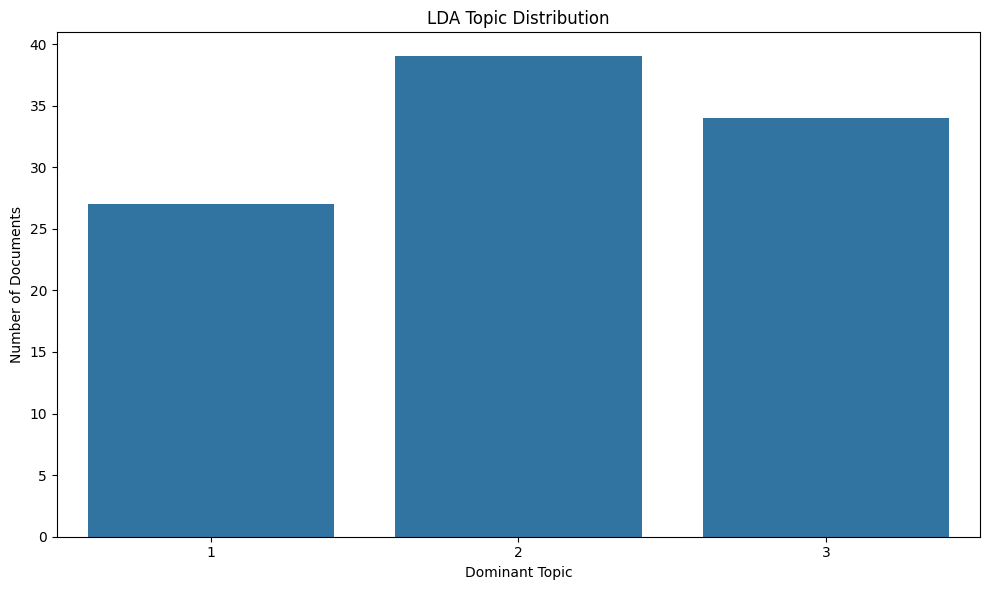

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=lda_topic_distribution,
    x="topic",
    y="document_count"
)
plt.title("LDA Topic Distribution")
plt.xlabel("Dominant Topic")
plt.ylabel("Number of Documents")
plt.tight_layout()
plt.show()

# 11. Topic × Sentiment Analysis

This is one of the most valuable analytical steps in the project.

Instead of asking only:

> What sentiment exists?

we ask:

> **Which topics are associated with which sentiment?**

For a real customer-review dataset, this could reveal issues such as:

```text
Battery       → Mostly Positive
Pricing       → Mostly Negative
Delivery      → Mixed
Quality       → Strongly Positive
```

For the current Quotes to Scrape corpus, interpret the result as an NLP demonstration rather than customer intelligence.

In [22]:
# Prefer the sentiment result generated in Notebook 04.
if sentiment_df is not None and "quote_id" in df.columns and "quote_id" in sentiment_df.columns:
    sentiment_cols = ["quote_id"]

    if "sentiment" in sentiment_df.columns:
        sentiment_cols.append("sentiment")
    if "predicted_sentiment" in sentiment_df.columns:
        sentiment_cols.append("predicted_sentiment")
    if "compound_score" in sentiment_df.columns:
        sentiment_cols.append("compound_score")

    topic_sentiment_df = df.merge(
        sentiment_df[sentiment_cols].drop_duplicates("quote_id"),
        on="quote_id",
        how="left"
    )
else:
    topic_sentiment_df = df.copy()

if "sentiment" in topic_sentiment_df.columns:
    topic_sentiment_df["analysis_sentiment"] = topic_sentiment_df["sentiment"]
elif "predicted_sentiment" in topic_sentiment_df.columns:
    topic_sentiment_df["analysis_sentiment"] = topic_sentiment_df["predicted_sentiment"]
else:
    topic_sentiment_df["analysis_sentiment"] = np.nan

display(
    topic_sentiment_df[
        ["processed_text", "lda_dominant_topic", "analysis_sentiment"]
    ].head(10)
)

,processed_text,lda_dominant_topic,analysis_sentiment
0,world created process thinking changed without changing thinking,3,Positive
1,choice harry show truly far ability,2,Positive
2,two way live life one though nothing miracle though everything miracle,2,Negative
3,person gentleman lady pleasure good novel must intolerably stupid,2,Positive
4,imperfection beauty madness genius better absolutely ridiculous absolutely boring,3,Negative
5,try become man success rather become man value,1,Positive
6,better hated loved,2,Positive
7,failed ive found way wont work,2,Negative
8,woman like tea bag never know strong hot water,2,Negative
9,day without sunshine like know night,2,Negative


In [23]:
if topic_sentiment_df["analysis_sentiment"].notna().any():
    topic_sentiment_summary = pd.crosstab(
        topic_sentiment_df["lda_dominant_topic"],
        topic_sentiment_df["analysis_sentiment"],
        normalize="index"
    ).mul(100).round(2)

    display(topic_sentiment_summary)
else:
    topic_sentiment_summary = pd.DataFrame()
    print("No sentiment labels available for topic × sentiment analysis.")

analysis_sentiment,Negative,Neutral,Positive
lda_dominant_topic,,,
1,25.93,22.22,51.85
2,30.77,17.95,51.28
3,38.24,23.53,38.24


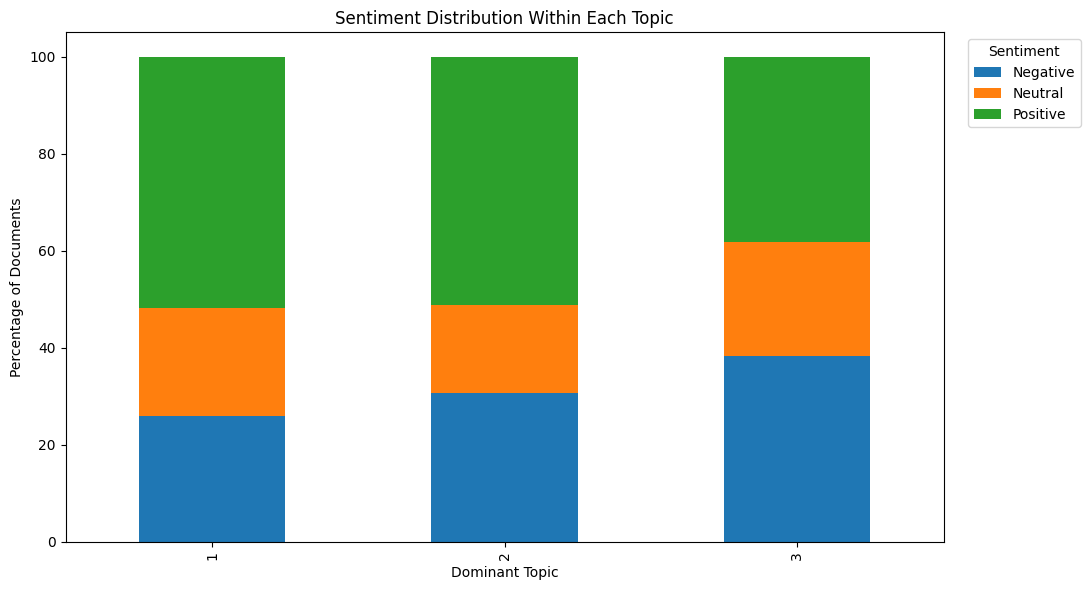

In [24]:
if not topic_sentiment_summary.empty:
    topic_sentiment_summary.plot(
        kind="bar",
        stacked=True,
        figsize=(11, 6)
    )
    plt.title("Sentiment Distribution Within Each Topic")
    plt.xlabel("Dominant Topic")
    plt.ylabel("Percentage of Documents")
    plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# 12. Topic-Level Document Examples

Numbers alone are not enough.

We inspect representative documents from each topic to validate whether the extracted topic appears semantically coherent.

In [25]:
for topic_id in sorted(df["lda_dominant_topic"].unique()):
    print("=" * 90)
    print(f"TOPIC {topic_id}")
    print("=" * 90)

    sample_rows = df[df["lda_dominant_topic"] == topic_id].nlargest(
        3, "lda_topic_score"
    )

    for _, row in sample_rows.iterrows():
        print(f"Score: {row['lda_topic_score']:.4f}")
        print("Text :", row["processed_text"])
        print()

TOPIC 1
Score: 0.9966
Text : life make matter youre going mess sometimes universal truth good part get decide youre going mess girl friend theyll act like anyway remember come go one stay everything theyre true best friend dont let go also remember sister make best friend world lover well theyll come go baby hate say actually pretty much going break heart cant give give youll never find soulmate youll never find half make whole go everything fail doesnt mean youre gon na fail everything keep trying hold always always always believe dont sweetie keep head high keep chin importantly keep smiling life beautiful thing there much smile

Score: 0.9940
Text : may first last loved may love love else matter shes perfect arent either two may never perfect together make laugh cause think twice admit human making mistake hold onto give may thinking every second day give part know break heart dont hurt dont change dont analyze dont expect give smile make happy let know make mad miss shes

Score: 0.

# 13. Optional Advanced Keyword Extraction — KeyBERT

**KeyBERT** uses transformer-based embeddings to identify phrases that are semantically representative of a document.

It can be useful for advanced projects, but it is intentionally optional because it adds extra dependencies and model downloads.

The classical TF-IDF + n-gram approach above is sufficient for the baseline project.

In [26]:
# Optional: install only if you want embedding-based keyword extraction.
# !pip install keybert sentence-transformers

try:
    from keybert import KeyBERT

    keybert_model = KeyBERT()
    sample_text = df["processed_text"].iloc[0]

    keybert_keywords = keybert_model.extract_keywords(
        sample_text,
        keyphrase_ngram_range=(1, 2),
        stop_words=None,
        top_n=5
    )

    print("Example KeyBERT keywords:")
    display(pd.DataFrame(keybert_keywords, columns=["keyword", "score"]))

except ImportError:
    print(
        "KeyBERT is not installed. This optional section is skipped. "
        "The main keyword/topic pipeline does not depend on it."
    )
except Exception as exc:
    print(f"KeyBERT could not be executed in this environment: {exc}")

KeyBERT is not installed. This optional section is skipped. The main keyword/topic pipeline does not depend on it.


# 14. Build Keyword Analysis Output

We create a reusable keyword table containing:

- keyword / n-gram
- mean TF-IDF
- corpus frequency

This can later be consumed by the dashboard or reporting layer.

In [27]:
keyword_analysis = tfidf_keywords.merge(
    word_frequency,
    on="keyword",
    how="left"
)

keyword_analysis["frequency"] = keyword_analysis["frequency"].fillna(0).astype(int)

keyword_analysis = keyword_analysis[
    ["keyword", "mean_tfidf", "frequency"]
].sort_values(
    ["mean_tfidf", "frequency"],
    ascending=[False, False]
).reset_index(drop=True)

display(keyword_analysis.head(30))

,keyword,mean_tfidf,frequency
0,love,0.025317,24
1,life,0.022377,17
2,one,0.022093,17
3,never,0.019589,13
4,book,0.017744,10
5,thing,0.016790,10
6,think,0.015165,14
7,know,0.015152,8
8,like,0.014778,9
9,people,0.014629,7


# 15. Build Topic Analysis Output

The final topic table keeps the original text context together with the topic assignments and topic confidence-like weights.

> The topic score is a model weight, not a calibrated probability.

In [28]:
topic_analysis = topic_sentiment_df.copy()

topic_analysis = topic_analysis[
    [
        col for col in [
            "quote_id",
            "original_text",
            "processed_text",
            "author",
            "tags",
            "source_url",
            "analysis_sentiment",
            "compound_score",
            "lda_dominant_topic",
            "lda_topic_score",
            "nmf_dominant_topic",
            "nmf_topic_score"
        ]
        if col in topic_analysis.columns
    ]
].copy()

display(topic_analysis.head())

,quote_id,original_text,processed_text,author,tags,source_url,analysis_sentiment,compound_score,lda_dominant_topic,lda_topic_score,nmf_dominant_topic,nmf_topic_score
0,1,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,world created process thinking changed without changing thinking,Albert Einstein,"change, deep-thoughts, thinking, world",https://quotes.toscrape.com/,Positive,0.2500,3,0.957324,3,0.062148
1,2,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",choice harry show truly far ability,J.K. Rowling,"abilities, choices",https://quotes.toscrape.com/,Positive,0.6369,2,0.942403,1,0.023429
2,3,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything...,two way live life one though nothing miracle though everything miracle,Albert Einstein,"inspirational, life, live, miracle, miracles",https://quotes.toscrape.com/,Negative,-0.7306,2,0.968235,2,0.424442
3,4,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",person gentleman lady pleasure good novel must intolerably stupid,Jane Austen,"aliteracy, books, classic, humor",https://quotes.toscrape.com/,Positive,0.6705,2,0.961843,1,0.088947
4,5,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",imperfection beauty madness genius better absolutely ridiculous absolutely boring,Marilyn Monroe,"be-yourself, inspirational",https://quotes.toscrape.com/,Negative,-0.2143,3,0.962617,1,0.016669


# 16. Topic Summary Table

This summary is designed for downstream reporting and dashboards.

It combines topic size with sentiment composition when sentiment is available.

In [29]:
topic_summary = (
    topic_analysis
    .groupby("lda_dominant_topic")
    .agg(
        document_count=("processed_text", "count"),
        avg_topic_score=("lda_topic_score", "mean")
    )
    .reset_index()
    .rename(columns={"lda_dominant_topic": "topic"})
)

topic_summary["document_percentage"] = (
    topic_summary["document_count"] / len(topic_analysis) * 100
).round(2)

topic_words_map = dict(
    zip(
        range(1, N_TOPICS + 1),
        lda_topics["top_words"]
    )
)

topic_summary["top_words"] = topic_summary["topic"].map(topic_words_map)

display(topic_summary)

,topic,document_count,avg_topic_score,document_percentage,top_words
0,1,27,0.953865,27.0,"make, friend, go, dont, keep, going, may, never, remember, good"
1,2,39,0.952760,39.0,"love, think, life, way, read, know, live, thing, one, want"
2,3,34,0.934678,34.0,"one, truth, opposite, indifference, life, never, love, book, day, world"


# 17. Save Analysis Outputs

We now persist the analytical outputs so Notebook 06 and the future Streamlit dashboard can reuse them without rerunning every modeling step.

In [30]:
keyword_analysis.to_csv(KEYWORD_OUTPUT, index=False)
topic_analysis.to_csv(TOPIC_OUTPUT, index=False)
topic_summary.to_csv(TOPIC_SUMMARY_OUTPUT, index=False)

# Save useful visualization-ready tables as well.
bigrams.to_csv(TABLES_DIR / "top_bigrams.csv", index=False)
trigrams.to_csv(TABLES_DIR / "top_trigrams.csv", index=False)
lda_topics.to_csv(TABLES_DIR / "lda_topics.csv", index=False)
nmf_topics.to_csv(TABLES_DIR / "nmf_topics.csv", index=False)

print("Saved:")
print(" -", KEYWORD_OUTPUT)
print(" -", TOPIC_OUTPUT)
print(" -", TOPIC_SUMMARY_OUTPUT)
print(" -", TABLES_DIR / "top_bigrams.csv")
print(" -", TABLES_DIR / "top_trigrams.csv")
print(" -", TABLES_DIR / "lda_topics.csv")
print(" -", TABLES_DIR / "nmf_topics.csv")

Saved:
 - D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\final\keyword_analysis.csv
 - D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\final\topic_analysis.csv
 - D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\final\topic_summary.csv
 - D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\outputs\tables\top_bigrams.csv
 - D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\outputs\tables\top_trigrams.csv
 - D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\outputs\tables\lda_topics.csv
 - D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\outputs\tables\nmf_topics.csv


# 18. Final Quality Checks

Before moving to Notebook 06, we verify that:

- keyword output exists
- topic output exists
- topic count is valid
- topic assignments are not missing
- saved files can be reloaded


In [31]:
assert KEYWORD_OUTPUT.exists()
assert TOPIC_OUTPUT.exists()
assert TOPIC_SUMMARY_OUTPUT.exists()

assert topic_analysis["lda_dominant_topic"].notna().all()
assert topic_analysis["nmf_dominant_topic"].notna().all()

reloaded_keywords = pd.read_csv(KEYWORD_OUTPUT)
reloaded_topics = pd.read_csv(TOPIC_OUTPUT)
reloaded_summary = pd.read_csv(TOPIC_SUMMARY_OUTPUT)

print("Keyword output shape:", reloaded_keywords.shape)
print("Topic output shape:", reloaded_topics.shape)
print("Topic summary shape:", reloaded_summary.shape)

print("\nQuality checks passed successfully.")

Keyword output shape: (1474, 3)
Topic output shape: (100, 12)
Topic summary shape: (3, 5)

Quality checks passed successfully.


# 19. Key Findings Framework

At this stage, the notebook has produced the analytical building blocks needed for final interpretation.

### Keyword Intelligence

We identified:

- most frequent words
- high TF-IDF keywords
- important bigrams
- important trigrams

### Topic Intelligence

We identified:

- latent topics using LDA
- latent topics using NMF
- dominant topic for every document
- topic distribution
- representative topic documents

### Sentiment Intelligence

Where Notebook 04 results are available, we connected:

```text
Topic
  +
Sentiment
  ↓
Topic-level sentiment profile
```

### Professional Interpretation Rule

Do **not** write:

> "Topic 2 definitely represents customer service."

unless the underlying dataset and domain evidence support that statement.

Instead write:

> "Topic 2 is characterized by terms such as X, Y, and Z and was interpreted as a possible service-related theme."

This distinction is important for trustworthy NLP reporting.

# 20. Notebook Summary

### Completed

```text
✅ Word Frequency Analysis
✅ TF-IDF Keyword Ranking
✅ Document-Level Keywords
✅ Bigram Analysis
✅ Trigram Analysis
✅ LDA Topic Modeling
✅ NMF Topic Modeling
✅ Dominant Topic Assignment
✅ Topic Distribution
✅ Topic × Sentiment Analysis
✅ Representative Document Inspection
✅ Optional KeyBERT Section
✅ Reusable Output Tables
✅ Quality Validation
```

### Main Outputs

```text
data/final/
├── keyword_analysis.csv
├── topic_analysis.csv
└── topic_summary.csv

outputs/tables/
├── top_bigrams.csv
├── top_trigrams.csv
├── lda_topics.csv
└── nmf_topics.csv
```

---

## 🚀 Next Notebook

### `06_Final_Insights.ipynb`

The next notebook will combine the complete project outputs:

```text
Sentiment
    +
Keywords
    +
Topics
    +
EDA Findings
    ↓
Final Insights
    ↓
Business / Analytical Recommendations
    ↓
Dashboard-Ready Dataset
```

**Notebook 05 complete.**
